# Annual users - improved model

The all-user model reproduced daily shape but under-called busy hours by ~60%.
Two populations were being averaged: annual users ride a **bimodal commuter**
pattern (8-9am, 17-19), casual users a **unimodal afternoon leisure** pattern.
Fitting one curve to both loses the peaks that matter.

This version targets annual users only - they pay upfront and ops prioritises
them. Pattern analysis: https://trip.arguswatcher.net/

**Scope is 2019-2022.** 2023 annual data is incomplete in the source (annual
share falls to 6.4% while total ridership grows), so it is excluded rather than
modelled. Annual volume and share both decline through 2022 - that is real and
stays in the data.

| Split | Years |
| --- | --- |
| train | 2019-2020 |
| validation | 2021 |
| test | 2022 |

---

## Step 1 - Data processing

**Out:** `data/cleaned/annual/`, `data/station_pool_annual.parquet`

The station pool is re-derived from annual trips. The all-user pool was ranked
on volume dominated by casual riders in later years, and commuter stations rank
differently from leisure ones - reusing it would import the bias this model
exists to remove.

In [1]:
from pathlib import Path

import duckdb
import pandas as pd

EXPORT = Path("/opt/data/export")
ML = Path("/opt/data/ml")
CLEANED = ML / "cleaned" / "annual"

FACT = f"read_parquet('{EXPORT}/fact_trip/**/*.parquet', hive_partitioning=1)"
DIM_STATION = f"read_parquet('{EXPORT}/dim_station/*.parquet')"
DIM_USER = f"read_parquet('{EXPORT}/dim_user_type/*.parquet')"

# carried over from the all-user run: 60s-24h keeps 99.8% of trips
DURATION_FILTER = "fact_trip_duration >= 60 AND fact_trip_duration <= 86400"
YEARS = (2019, 2020, 2021, 2022)
TOP_N = 50
SPAN_START, SPAN_END = "2019-01-31", "2022-12-01"

con = duckdb.connect()
con.execute("SET enable_progress_bar_print=false")

ANNUAL = f"""
    SELECT f.fact_trip_start_station_id AS station_id,
        f.fact_trip_start_date_id AS start_date,
        f.fact_trip_start_hour    AS hour,
        f.start_year              AS year
    FROM {FACT} f
    JOIN {DIM_USER} u ON u.dim_user_type_id = f.fact_trip_user_type_id
    WHERE {DURATION_FILTER}
      AND u.dim_user_type_name = 'annual'
      AND f.start_year IN {YEARS}
"""

print(con.execute(f"""
    SELECT year, count(*) AS trips FROM ({ANNUAL}) GROUP BY year ORDER BY year
""").df().to_string(index=False))

 year   trips
 2019 1844839
 2020 1867114
 2021 2134673
 2022 1632522


In [2]:
# Same two rules as the all-user pool: top 50 in any year, and operating across
# the whole span so the grid needs no per-station date bounds.
pool_df = con.execute(f"""
    WITH clean AS ({ANNUAL}),
    top50 AS (
        SELECT station_id, year,
            row_number() OVER (PARTITION BY year ORDER BY count(*) DESC) AS rnk
        FROM clean GROUP BY station_id, year
        QUALIFY rnk <= {TOP_N}
    ),
    life AS (
        SELECT station_id, min(start_date) AS first_trip,
            max(start_date) AS last_trip
        FROM clean GROUP BY station_id
    )
    SELECT l.station_id, s.dim_station_name AS station_name,
        l.first_trip, l.last_trip,
        count(DISTINCT t.year) AS top50_years, min(t.rnk) AS best_rank
    FROM life l
    JOIN top50 t USING (station_id)
    LEFT JOIN {DIM_STATION} s ON s.dim_station_id = l.station_id
    WHERE l.first_trip <= DATE '{SPAN_START}' AND l.last_trip >= DATE '{SPAN_END}'
    GROUP BY 1, 2, 3, 4 ORDER BY best_rank
""").df()

pool = sorted(pool_df["station_id"].tolist())
pool_sql = ", ".join(str(s) for s in pool)

assert pool_df["first_trip"].max() <= pd.Timestamp(SPAN_START), "a station opened late"
assert pool_df["last_trip"].min() >= pd.Timestamp(SPAN_END), "a station closed early"

print(f"annual pool: {len(pool)} stations")
pool_df.head(10)

annual pool: 73 stations


,station_id,station_name,first_trip,last_trip,top50_years,best_rank
0,7042,Sherbourne St / Wellesley St E,2019-01-01,2022-12-31,4,1
1,7076,York St / Queens Quay W,2019-01-01,2022-12-31,4,1
2,7006,Bay St / College St (East Side),2019-01-01,2022-12-31,4,1
3,7100,Dundas St E / Regent Park Blvd,2019-01-01,2022-12-31,4,2
4,7030,Bay St / Wellesley St W,2019-01-01,2022-12-31,4,2
5,7033,Union Station,2019-01-01,2022-12-31,2,3
6,7121,Jarvis St / Dundas St E,2019-01-01,2022-12-31,3,4
7,7322,King St W / Brant St,2019-01-01,2022-12-31,1,5
8,7078,College St / Major St,2019-01-01,2022-12-31,4,6
9,7059,Front St W / Blue Jays Way,2019-01-01,2022-12-31,1,7


In [ ]:
# If commuter and leisure stations really differ, the sets should not match.
all_user_pool = set(
    pd.read_parquet(ML / "station_pool.parquet")["station_id"]
)
shared = all_user_pool & set(pool)
print(f"all-user pool   {len(all_user_pool)} stations")
print(f"annual pool     {len(pool)} stations")
print(f"shared          {len(shared)}")
print(f"annual-only     {len(set(pool) - all_user_pool)}")

In [4]:
CLEAN = f"read_parquet('{CLEANED}/**/*.parquet', hive_partitioning=1)"

# Existence is not enough: an interrupted write leaves a footerless file that
# reads as corrupt rather than missing.
try:
    con.execute(f"SELECT count(*) FROM {CLEAN}").fetchone()
    cached = True
except Exception:
    cached = False

if cached:
    print(f"exists -> {CLEANED}")
else:
    CLEANED.mkdir(parents=True, exist_ok=True)
    con.execute(f"""
        COPY (
            SELECT * FROM ({ANNUAL}) WHERE station_id IN ({pool_sql})
        ) TO '{CLEANED}' (FORMAT parquet, PARTITION_BY year, OVERWRITE_OR_IGNORE 1)
    """)
    pool_df.to_parquet(ML / "station_pool_annual.parquet", index=False)
    print(f"wrote -> {CLEANED}")

summary = con.execute(f"""
    SELECT year, count(*) AS trips, count(DISTINCT station_id) AS stations,
        min(start_date) AS from_date, max(start_date) AS to_date
    FROM {CLEAN} GROUP BY year ORDER BY year
""").df()

assert summary["stations"].nunique() == 1, "station count varies by year"
print(summary.to_string(index=False))
print(f"\ntotal {summary['trips'].sum():,} annual trips")

exists -> /opt/data/ml/cleaned/annual


 year  trips  stations  from_date    to_date
 2019 681887        73 2019-01-01 2019-12-31
 2020 552081        73 2020-01-01 2020-12-31
 2021 619978        73 2021-01-01 2021-12-31
 2022 490673        73 2022-01-01 2022-12-31

total 2,344,619 annual trips


---

## Step 2 - Feature engineering

**Out:** `data/featured/annual/`

Same panel construction as the all-user version - cross join stations x observed
dates x 24 hours, zero-fill, join `dim_date`, cyclical encodings.

**New here: two prior-year features.** The all-user model was calendar-only
because the app supplies a future date and has no recent history. Under a
one-year staleness assumption that constraint loosens - predicting July 2023
needs only 2022 data, which is available. These give the model a per-station
demand level it was previously blind to:

- `py_station_hour_weekday_mean` - same station, hour and weekday, prior year
- `py_station_month_mean` - same station and month, prior year

Both are computed from the **prior calendar year only**, so a row in 2022 sees
2021 and nothing later. 2019 rows have no prior year and stay NaN;
HistGradientBoosting handles missing values natively.

In [5]:
import numpy as np

FEATURED = ML / "featured" / "annual"
DIM_DATE = f"read_parquet('{EXPORT}/dim_date/*.parquet')"

# Grid over observed dates only: days with no annual trips network-wide are
# system-idle, not zero demand, so they must not be zero-filled.
panel = con.execute(f"""
    WITH dates AS (SELECT DISTINCT start_date FROM {CLEAN}),
    hours AS (SELECT unnest(generate_series(0, 23)) AS hour),
    grid AS (
        SELECT s.station_id, d.start_date, h.hour
        FROM (SELECT unnest([{pool_sql}]) AS station_id) s
        CROSS JOIN dates d CROSS JOIN hours h
    ),
    counts AS (
        SELECT station_id, start_date, hour, count(*) AS trip_count
        FROM {CLEAN} GROUP BY 1, 2, 3
    )
    SELECT g.station_id, g.start_date, g.hour,
        coalesce(c.trip_count, 0) AS trip_count
    FROM grid g LEFT JOIN counts c USING (station_id, start_date, hour)
""").df()

trips_in = con.execute(f"SELECT count(*) FROM {CLEAN}").fetchone()[0]
assert panel["trip_count"].sum() == trips_in, "zero-fill changed the trip total"
assert not panel.duplicated(["station_id", "start_date", "hour"]).any(), "grain broken"

print(f"panel {len(panel):,} rows | {(panel['trip_count'] == 0).mean():.1%} zero")

panel 2,507,112 rows | 58.0% zero


In [6]:
con.register("panel", panel)

featured = con.execute(f"""
    WITH cal AS (
        SELECT p.station_id, p.start_date, p.hour, p.trip_count,
            d.dim_date_year AS year, d.dim_date_quarter AS quarter,
            d.dim_date_month AS month, d.dim_date_weekday AS weekday,
            d.dim_date_week AS week_of_year,
            d.dim_date_is_weekend AS is_weekend,
            d.dim_date_is_holiday AS is_holiday,
            d.dim_date_season AS season
        FROM panel p
        JOIN {DIM_DATE} d ON d.dim_date_id = p.start_date
    ),
    -- prior-year aggregates, keyed on year+1 so a row only ever sees the year
    -- before it
    py_hour AS (
        SELECT station_id, year + 1 AS year, hour, weekday,
            avg(trip_count) AS py_station_hour_weekday_mean
        FROM cal GROUP BY station_id, year, hour, weekday
    ),
    py_month AS (
        SELECT station_id, year + 1 AS year, month,
            avg(trip_count) AS py_station_month_mean
        FROM cal GROUP BY station_id, year, month
    )
    SELECT c.*, h.py_station_hour_weekday_mean, m.py_station_month_mean
    FROM cal c
    LEFT JOIN py_hour  h USING (station_id, year, hour, weekday)
    LEFT JOIN py_month m USING (station_id, year, month)
""").df()

assert len(featured) == len(panel), "a join changed the row count"
# 2019 has no prior year; every later year must be fully covered
assert featured.loc[featured["year"] == 2019, "py_station_month_mean"].isna().all()
assert featured.loc[featured["year"] > 2019, "py_station_month_mean"].notna().all()

print(featured.groupby("year")["py_station_hour_weekday_mean"]
      .apply(lambda s: f"{s.notna().mean():.0%} populated").to_string())

year
2019      0% populated
2020    100% populated
2021    100% populated
2022    100% populated


In [7]:
def cyclical(df, col, period):
    """Hour 23 and hour 0 are adjacent; as raw integers they are 23 apart."""
    theta = 2 * np.pi * df[col] / period
    df[f"{col}_sin"] = np.sin(theta)
    df[f"{col}_cos"] = np.cos(theta)


for col, period in [("hour", 24), ("weekday", 7), ("month", 12)]:
    cyclical(featured, col, period)

featured["is_weekend"] = featured["is_weekend"].astype("int8")
featured["is_holiday"] = featured["is_holiday"].astype("int8")

OUT = f"read_parquet('{FEATURED}/**/*.parquet', hive_partitioning=1)"


def readable(path):
    """Existence is not enough - an interrupted write leaves a file with no
    parquet footer, which then reads as corrupt rather than missing."""
    files = list(path.glob("year=*/*.parquet"))
    if not files:
        return False
    try:
        for f in files:
            pd.read_parquet(f, columns=["trip_count"])
        return True
    except Exception:
        return False


if readable(FEATURED):
    print(f"exists -> {FEATURED}")
else:
    # write a year at a time: one 2.5M-row COPY peaks high enough to OOM the
    # container when models are also resident
    FEATURED.mkdir(parents=True, exist_ok=True)
    for yr, part in featured.groupby("year"):
        d = FEATURED / f"year={yr}"
        d.mkdir(exist_ok=True)
        part.drop(columns="year").to_parquet(d / "data_0.parquet", index=False)
    print(f"wrote -> {FEATURED}")

summary = con.execute(f"""
    SELECT year, count(*) AS rows, sum(trip_count) AS trips,
        round(100.0 * count(*) FILTER (trip_count = 0) / count(*), 1) AS pct_zero
    FROM {OUT} GROUP BY year ORDER BY year
""").df()

assert summary["trips"].sum() == trips_in, "trips lost in the write"
print(summary.to_string(index=False))

exists -> /opt/data/ml/featured/annual


 year   rows    trips  pct_zero
 2019 639480 681887.0      56.6
 2020 641232 552081.0      59.9
 2021 639480 619978.0      56.5
 2022 586920 490673.0      59.0


---

## Step 3 - Model selection

The all-user run already settled the algorithm: HistGradientBoosting with
Poisson loss beat a Poisson GLM by 11% against the GLM's 0.1%. Re-running that
comparison would answer a question already answered.

The open question here is whether the **prior-year features earn their place**,
so the comparison is between feature sets on identical data:

| Candidate | Features |
| --- | --- |
| baseline | station x hour x weekday mean |
| calendar | the all-user feature set |
| calendar + prior year | adds the two `py_*` columns |

Ranked on validation (2021). Test (2022) stays sealed until evaluation.

In [8]:
import gc

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

TARGET = "trip_count"
TRAIN_YEARS, VAL_YEARS, TEST_YEARS = (2019, 2020), (2021,), (2022,)
PEAK_HOURS = [7, 8, 9, 16, 17, 18, 19]
BUSY_THRESHOLD = 11

CALENDAR = [
    "station_id", "season",
    "hour", "quarter", "month", "weekday", "week_of_year",
    "is_weekend", "is_holiday",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
]
PRIOR_YEAR = ["py_station_hour_weekday_mean", "py_station_month_mean"]
KEEP = CALENDAR + PRIOR_YEAR + [TARGET, "start_date", "year"]

train = featured.loc[featured["year"].isin(TRAIN_YEARS), KEEP].copy()
val = featured.loc[featured["year"].isin(VAL_YEARS), KEEP].copy()
test = featured.loc[featured["year"].isin(TEST_YEARS), KEEP].copy()

del panel
con.unregister("panel")
gc.collect()

assert train["start_date"].max() < val["start_date"].min(), "train/val overlap"
assert val["start_date"].max() < test["start_date"].min(), "val/test overlap"

print(f"train {len(train):>9,}  {TRAIN_YEARS}")
print(f"val   {len(val):>9,}  {VAL_YEARS}")
print(f"test  {len(test):>9,}  {TEST_YEARS}")
# half the training rows are 2019, which has no prior year
print(f"\ntrain rows with prior-year features: "
      f"{train['py_station_month_mean'].notna().mean():.0%}")

train 1,280,712  (2019, 2020)
val     639,480  (2021,)
test    586,920  (2022,)

train rows with prior-year features: 50%


In [9]:
def score(y_true, y_pred, hours):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    peak = np.isin(hours, PEAK_HOURS)
    busy = y_true >= BUSY_THRESHOLD
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_busy": mean_absolute_error(y_true[busy], y_pred[busy]),
    }


def build(features):
    return Pipeline([
        ("prep", ColumnTransformer(
            [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
              ["season"])],
            remainder="passthrough",
        )),
        ("model", HistGradientBoostingRegressor(
            loss="poisson", learning_rate=0.1, max_leaf_nodes=31,
            max_iter=300, early_stopping=False, random_state=0,
        )),
    ]), features


BASELINE_KEYS = ["station_id", "hour", "weekday"]
lookup = train.groupby(BASELINE_KEYS)[TARGET].mean().rename("p")
baseline_val = (val[BASELINE_KEYS].join(lookup, on=BASELINE_KEYS)["p"]
                .fillna(train[TARGET].mean()).to_numpy())

candidates = {"baseline": baseline_val}
fitted = {}
for name, feats in [("calendar", CALENDAR), ("calendar+py", CALENDAR + PRIOR_YEAR)]:
    model, cols = build(feats)
    model.fit(train[cols], train[TARGET])
    candidates[name] = model.predict(val[cols])
    fitted[name] = (model, cols)

selection = pd.DataFrame(
    {n: score(val[TARGET], p, val["hour"]) for n, p in candidates.items()}
).T
selection["vs_baseline"] = 1 - selection["MAE"] / selection.loc["baseline", "MAE"]

print("validation (2021)\n")
print(selection.to_string())

validation (2021)

                  MAE      RMSE  MAE_peak   MAE_busy  vs_baseline
baseline     0.920902  1.480829  1.452159  10.110739     0.000000
calendar     0.830232  1.363038  1.281746   9.121501     0.098458
calendar+py  0.809375  1.334665  1.194257   9.599893     0.121106


In [10]:
from sklearn.inspection import permutation_importance

# Does the model actually lean on the prior-year columns, or did MAE move for
# some other reason? Shuffling a column that matters degrades the score.
model, cols = fitted["calendar+py"]
sample = val.sample(60_000, random_state=0)

imp = permutation_importance(
    model, sample[cols], sample[TARGET],
    scoring="neg_mean_absolute_error", n_repeats=3, random_state=0, n_jobs=-1,
)

importance = (
    pd.DataFrame({"feature": cols, "mae_increase": imp.importances_mean})
    .sort_values("mae_increase", ascending=False)
    .head(8)
    .reset_index(drop=True)
)
importance

,feature,mae_increase
0,hour,0.072113
1,py_station_hour_weekday_mean,0.054747
2,station_id,0.036243
3,hour_sin,0.027914
4,week_of_year,0.027350
5,py_station_month_mean,0.021877
6,month_cos,0.017304
7,month_sin,0.007920


---

## Step 4 - Persist the split

**Out:** `data/split/annual/`

The feature set is settled, so the split is frozen to disk. Later steps read
these files rather than re-deriving from `data/featured/annual` - runs are only
comparable if they saw byte-identical rows.

`split.json` carries the contract: target, feature list, year assignments, and
the validation baseline to beat.

In [11]:
import json

SPLIT = ML / "split" / "annual"
SPLIT.mkdir(parents=True, exist_ok=True)

FEATURES = CALENDAR + PRIOR_YEAR

for name, df in [("train", train), ("val", val), ("test", test)]:
    df.to_parquet(SPLIT / f"{name}.parquet", index=False)
    print(f"{name:6} {len(df):>9,} rows -> {name}.parquet")

(SPLIT / "split.json").write_text(json.dumps({
    "segment": "annual",
    "target": TARGET,
    "features": FEATURES,
    "categorical": ["station_id", "season"],
    "prior_year": PRIOR_YEAR,
    "peak_hours": PEAK_HOURS,
    "busy_threshold": BUSY_THRESHOLD,
    "train_years": list(TRAIN_YEARS),
    "val_years": list(VAL_YEARS),
    "test_years": list(TEST_YEARS),
    "station_pool": pool,
    "selected_model": "hist_gbm_poisson",
    "baseline_val_MAE": float(selection.loc["baseline", "MAE"]),
}, indent=2))

print(f"\ncontract -> split.json ({len(FEATURES)} features, {len(pool)} stations)")

train  1,280,712 rows -> train.parquet


val      639,480 rows -> val.parquet


test     586,920 rows -> test.parquet

contract -> split.json (17 features, 73 stations)


In [12]:
# Read back from disk: two writes in this project were silently truncated by an
# OOM, so a write is not done until it reads.
contract = json.loads((SPLIT / "split.json").read_text())
back = {n: pd.read_parquet(SPLIT / f"{n}.parquet") for n in ("train", "val", "test")}

check = pd.DataFrame([
    {"split": n, "rows": len(d), "trips": int(d[TARGET].sum()),
     "from": d["start_date"].min().date(), "to": d["start_date"].max().date()}
    for n, d in back.items()
]).set_index("split")

assert check.loc["train", "rows"] == len(train), "train rows changed on write"
assert back["train"]["start_date"].max() < back["val"]["start_date"].min()
assert back["val"]["start_date"].max() < back["test"]["start_date"].min()
assert set(contract["features"]).issubset(back["train"].columns)

print(check.to_string())
print(f"\ntotal {check['trips'].sum():,} annual trips across the split")

          rows    trips        from          to
split                                          
train  1280712  1233968  2019-01-01  2020-12-31
val     639480   619978  2021-01-01  2021-12-31
test    586920   490673  2022-01-01  2022-12-31

total 2,344,619 annual trips across the split


---

## Step 5 - Baseline

Mean departures per `(station, hour, weekday)`, learned on train and applied
unchanged. Cells unseen in training fall back to the global mean.

Step 3 scored a baseline on validation to rank feature sets. This one is scored
on **test**, so evaluation has a bar that was fixed before any model saw 2022.
It is logged to MLflow alongside the models - a metric with no reference point
is not interpretable.

In [13]:
import os

import mlflow

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("bike-demand-annual")

DATA_CONTEXT = {
    "segment": "annual",
    "rows_train": len(train),
    "rows_val": len(val),
    "rows_test": len(test),
    "n_stations": len(pool),
    "train_years": str(TRAIN_YEARS),
    "val_years": str(VAL_YEARS),
    "test_years": str(TEST_YEARS),
    "features": ",".join(FEATURES),
}


def predict_baseline(df):
    return (df[BASELINE_KEYS].join(lookup, on=BASELINE_KEYS)["p"]
            .fillna(train[TARGET].mean()).to_numpy())


with mlflow.start_run(run_name="baseline") as run:
    mlflow.log_params({"method": "station_hour_weekday_mean",
                       "fallback": "global_mean"})
    mlflow.set_tags({"model": "baseline", "version": "baseline", **DATA_CONTEXT})

    baseline_scores = {}
    for split_name, df in [("val", val), ("test", test)]:
        s = score(df[TARGET], predict_baseline(df), df["hour"])
        mlflow.log_metrics({f"{split_name}_{k}": v for k, v in s.items()})
        baseline_scores[split_name] = s

    baseline_run_id = run.info.run_id

baseline_df = pd.DataFrame(baseline_scores).T
print(f"run_id {baseline_run_id}")
print(f"{len(lookup):,} station-hour-weekday cells\n")
print(baseline_df.to_string())

🏃 View run baseline at: http://mlflow:5000/#/experiments/2/runs/0a90b491683142c690e334a1fdbc7610
🧪 View experiment at: http://mlflow:5000/#/experiments/2
run_id 0a90b491683142c690e334a1fdbc7610
12,264 station-hour-weekday cells

           MAE      RMSE  MAE_peak   MAE_busy
val   0.920902  1.480829  1.452159  10.110739
test  0.864520  1.325291  1.363152   8.230635


In [14]:
profile = test.groupby(["hour", "is_weekend"])[TARGET].mean().unstack()
profile.columns = ["weekday", "weekend"]

peaks = profile["weekday"].nlargest(3).sort_index()
print("mean departures per station-hour, test 2022\n")
print(profile.round(3).to_string())
print(f"\nbusiest weekday hours: {list(peaks.index)}")

mean departures per station-hour, test 2022

      weekday  weekend
hour                  
0       0.271    0.475
1       0.145    0.379
2       0.085    0.329
3       0.047    0.173
4       0.057    0.092
5       0.137    0.080
6       0.414    0.136
7       0.835    0.282
8       1.431    0.419
9       1.003    0.645
10      0.755    0.878
11      0.843    1.025
12      1.009    1.113
13      1.036    1.221
14      1.020    1.253
15      1.203    1.294
16      1.678    1.316
17      2.317    1.306
18      2.025    1.272
19      1.541    1.114
20      1.148    0.869
21      0.893    0.716
22      0.700    0.607
23      0.521    0.491

busiest weekday hours: [16, 17, 18]


---

## Step 6 - Hyperparameter sweep

Eight candidates, each a nested MLflow run under one parent so the search reads
as a single unit.

**Ranked on validation (2021); test stays sealed.** Selecting on test would
leak it and make step 7's numbers meaningless.

The all-user sweep moved MAE by 0.15% across ten candidates - gradient boosting
on tabular data is not very sensitive to these settings. The expectation here is
similar, so the grid is small and includes `max_features`, which the earlier
grid lacked and which matters more now there are 17 features.

In [15]:
BASE = {"loss": "poisson", "early_stopping": False, "random_state": 0}

GRID = [
    {"learning_rate": 0.1, "max_leaf_nodes": 31, "max_iter": 300},   # step 3 default
    {"learning_rate": 0.1, "max_leaf_nodes": 63, "max_iter": 300},
    {"learning_rate": 0.1, "max_leaf_nodes": 127, "max_iter": 300},
    {"learning_rate": 0.05, "max_leaf_nodes": 63, "max_iter": 600},
    {"learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600},
    # larger leaves resist fitting noise in the 58% of rows that are zero
    {"learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600,
     "min_samples_leaf": 100},
    {"learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600,
     "l2_regularization": 1.0},
    # column subsampling: 17 features, several of them correlated
    {"learning_rate": 0.05, "max_leaf_nodes": 127, "max_iter": 600,
     "max_features": 0.7},
]

results = []
with mlflow.start_run(run_name="sweep") as parent:
    mlflow.set_tags({"model": "hist_gbm", "version": "sweep", **DATA_CONTEXT})
    mlflow.log_param("n_candidates", len(GRID))

    for i, overrides in enumerate(GRID):
        params = {**BASE, **overrides}
        with mlflow.start_run(run_name=f"cand_{i:02d}", nested=True):
            mlflow.log_params(params)
            model, cols = build(FEATURES)
            model.set_params(**{f"model__{k}": v for k, v in params.items()})
            model.fit(train[cols], train[TARGET])

            # validation only - test is not touched until the winner is refit
            s = score(val[TARGET], model.predict(val[cols]), val["hour"])
            mlflow.log_metrics({f"val_{k}": v for k, v in s.items()})

        results.append({**overrides, **{f"val_{k}": v for k, v in s.items()}})
        print(f"cand_{i:02d}  val MAE {s['MAE']:.4f}  busy {s['MAE_busy']:.3f}")
        del model
        gc.collect()

leaderboard = pd.DataFrame(results).sort_values("val_MAE").reset_index(drop=True)
print(f"\nbest {leaderboard.loc[0, 'val_MAE']:.4f} | "
      f"worst {leaderboard['val_MAE'].max():.4f} | "
      f"spread {leaderboard['val_MAE'].max() / leaderboard['val_MAE'].min() - 1:.2%}")

🏃 View run cand_00 at: http://mlflow:5000/#/experiments/2/runs/a6b85e498ffd42dd89a3a89b1bc37f76
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_00  val MAE 0.8094  busy 9.600


🏃 View run cand_01 at: http://mlflow:5000/#/experiments/2/runs/e46a2c2d64cb4ae6bdf486241d794b59
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_01  val MAE 0.8162  busy 9.507


🏃 View run cand_02 at: http://mlflow:5000/#/experiments/2/runs/d2c84035f9fd4225bd7caffd043a4da4
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_02  val MAE 0.8141  busy 9.562


🏃 View run cand_03 at: http://mlflow:5000/#/experiments/2/runs/448f417c5dd14e43889d9406350f3dd9
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_03  val MAE 0.8097  busy 9.593


🏃 View run cand_04 at: http://mlflow:5000/#/experiments/2/runs/e9abbde258fa45f0960db5d332fbdcaa
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_04  val MAE 0.8082  busy 9.537


🏃 View run cand_05 at: http://mlflow:5000/#/experiments/2/runs/bcc5da723f2147728a9253be8ff78cc9
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_05  val MAE 0.8093  busy 9.406


🏃 View run cand_06 at: http://mlflow:5000/#/experiments/2/runs/e918645a20914da7a9457980092bc8e2
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_06  val MAE 0.8100  busy 9.587


🏃 View run cand_07 at: http://mlflow:5000/#/experiments/2/runs/52b398ca90f346bc967e23ae6721ae16
🧪 View experiment at: http://mlflow:5000/#/experiments/2
cand_07  val MAE 0.8083  busy 9.580


🏃 View run sweep at: http://mlflow:5000/#/experiments/2/runs/d4f3704324ba4196a8688b35943618de
🧪 View experiment at: http://mlflow:5000/#/experiments/2

best 0.8082 | worst 0.8162 | spread 0.99%


In [16]:
leaderboard.fillna("-")

,learning_rate,max_leaf_nodes,max_iter,val_MAE,val_RMSE,val_MAE_peak,val_MAE_busy,min_samples_leaf,l2_regularization,max_features
0,0.05,127,600,0.808166,1.343278,1.198705,9.536846,-,-,-
1,0.05,127,600,0.808291,1.341739,1.194038,9.579653,-,-,0.7
2,0.05,127,600,0.809317,1.343420,1.199470,9.405731,100.0,-,-
3,0.10,31,300,0.809375,1.334665,1.194257,9.599893,-,-,-
4,0.05,63,600,0.809694,1.336902,1.197597,9.593461,-,-,-
5,0.05,127,600,0.809990,1.344680,1.201860,9.587241,-,1.0,-
6,0.10,127,300,0.814077,1.353174,1.209482,9.562145,-,-,-
7,0.10,63,300,0.816203,1.348118,1.213430,9.506849,-,-,-


In [17]:
from mlflow.models import infer_signature

GRID_KEYS = ["learning_rate", "max_leaf_nodes", "max_iter",
             "min_samples_leaf", "l2_regularization", "max_features"]
INT_KEYS = {"max_leaf_nodes", "max_iter", "min_samples_leaf"}

best = leaderboard.loc[0, [k for k in GRID_KEYS if k in leaderboard]].dropna()
FINAL_PARAMS = {**BASE, **{
    k: int(v) if k in INT_KEYS else float(v) for k, v in best.items()
}}

# The winner is refit and scored on test here - the only time 2022 is touched.
final_model, cols = build(FEATURES)
final_model.set_params(**{f"model__{k}": v for k, v in FINAL_PARAMS.items()})

# Dataset digests make "trained on the same rows" checkable rather than assumed.
train_ds = mlflow.data.from_pandas(
    train[FEATURES + [TARGET]], name="annual-split-train", targets=TARGET
)
test_ds = mlflow.data.from_pandas(
    test[FEATURES + [TARGET]], name="annual-split-test", targets=TARGET
)

with mlflow.start_run(run_name="hist_gbm_final") as run:
    mlflow.log_params(FINAL_PARAMS)
    mlflow.set_tags({"model": "hist_gbm", "version": "final",
                     "selected_on": "val_MAE", **DATA_CONTEXT})
    mlflow.log_input(train_ds, context="training")
    mlflow.log_input(test_ds, context="evaluation")

    final_model.fit(train[cols], train[TARGET])

    final_scores = {}
    for split_name, df in [("val", val), ("test", test)]:
        s = score(df[TARGET], final_model.predict(df[cols]), df["hour"])
        mlflow.log_metrics({f"{split_name}_{k}": v for k, v in s.items()})
        final_scores[split_name] = s

    # signature + example: without them a serving process cannot validate a
    # request, and column order silently decides the prediction
    example = train[cols].head(5)
    mlflow.sklearn.log_model(
        final_model, name="model",
        signature=infer_signature(example, final_model.predict(example)),
        input_example=example,
        registered_model_name="annual-demand-poisson",
    )
    final_run_id = run.info.run_id

print(f"run_id {final_run_id}")
print(pd.Series(FINAL_PARAMS).to_frame("final").to_string())
print()
print(pd.DataFrame(final_scores).T.to_string())

/opt/conda/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


/opt/conda/lib/python3.13/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Successfully registered model 'annual-demand-poisson'.


2026/08/04 03:43:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: annual-demand-poisson, version 1


Created version '1' of model 'annual-demand-poisson'.


🏃 View run hist_gbm_final at: http://mlflow:5000/#/experiments/2/runs/cb0d4d18d3ce42b6a7e2f4564158ad2b
🧪 View experiment at: http://mlflow:5000/#/experiments/2
run_id cb0d4d18d3ce42b6a7e2f4564158ad2b
                  final
loss            poisson
early_stopping    False
random_state          0
learning_rate      0.05
max_leaf_nodes      127
max_iter            600

           MAE      RMSE  MAE_peak  MAE_busy
val   0.808166  1.343278  1.198705  9.536846
test  0.763613  1.216376  1.131107  8.629551


---

## Step 7 - Evaluation

Three questions:

1. How much better than the baseline, on test?
2. Does the segmentation fix the **under-prediction at busy hours** that the
   all-user model failed on? That was the point of the exercise - overall MAE
   was never the complaint.
3. Does the model reproduce the bimodal commuter shape, or only its average?

In [18]:
test_pred = np.clip(final_model.predict(test[cols]), 0, None)
base_pred = predict_baseline(test)

summary = pd.DataFrame({
    "baseline": score(test[TARGET], base_pred, test["hour"]),
    "final": score(test[TARGET], test_pred, test["hour"]),
}).T
summary["vs_baseline"] = 1 - summary["MAE"] / summary.loc["baseline", "MAE"]

print("test 2022\n")
print(summary.to_string())

bands = pd.cut(test[TARGET], [-0.1, 0, 2, 5, 10, np.inf],
               labels=["0", "1-2", "3-5", "6-10", "11+"])
pred_s = pd.Series(test_pred, index=test.index)

by_band = pd.DataFrame({
    "rows": test.groupby(bands, observed=True).size(),
    "mean_actual": test.groupby(bands, observed=True)[TARGET].mean(),
    "mean_pred": pred_s.groupby(bands, observed=True).mean(),
})
by_band["shortfall"] = 1 - by_band["mean_pred"] / by_band["mean_actual"]
by_band["pct_of_trips"] = (
    test.groupby(bands, observed=True)[TARGET].sum() / test[TARGET].sum()
)

print("\n\nby demand level\n")
print(by_band.round(3).to_string())

test 2022

               MAE      RMSE  MAE_peak  MAE_busy  vs_baseline
baseline  0.864520  1.325291  1.363152  8.230635      0.00000
final     0.763613  1.216376  1.131107  8.629551      0.11672


by demand level

              rows  mean_actual  mean_pred  shortfall  pct_of_trips
trip_count                                                         
0           346514        0.000      0.485       -inf         0.000
1-2         179457        1.322      1.119      0.154         0.484
3-5          51568        3.589      1.891      0.473         0.377
6-10          8822        6.963      2.767      0.603         0.125
11+            559       12.265      3.635      0.704         0.014


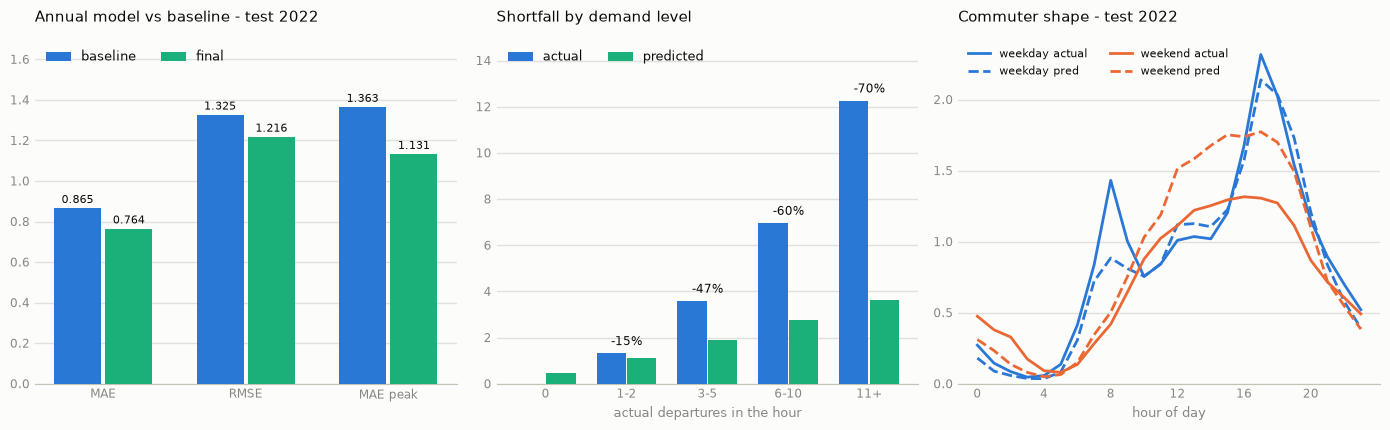

In [19]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID_C, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

pred_df = test[["hour", "is_weekend", TARGET]].copy()
pred_df["pred"] = test_pred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.4), facecolor=SURFACE)

metrics = ["MAE", "RMSE", "MAE_peak"]
x = np.arange(len(metrics))
for i, (name, color) in enumerate([("baseline", BLUE), ("final", AQUA)]):
    bars = ax1.bar(x + (i - 0.5) * 0.36, [summary.loc[name, m] for m in metrics],
                   0.33, label=name, color=color, zorder=3)
    # aqua is below 3:1 on this surface, so every bar is labelled
    ax1.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, color=INK)
ax1.set_xticks(x, ["MAE", "RMSE", "MAE peak"], fontsize=9, color=INK)
ax1.set_title("Annual model vs baseline - test 2022", fontsize=11, color=INK,
              loc="left", pad=12)
ax1.set_ylim(0, summary[metrics].to_numpy().max() * 1.25)
ax1.legend(frameon=False, ncols=2, fontsize=9, labelcolor=INK, loc="upper left")

bx = np.arange(len(by_band))
ax2.bar(bx - 0.19, by_band["mean_actual"], 0.36, label="actual", color=BLUE, zorder=3)
ax2.bar(bx + 0.19, by_band["mean_pred"], 0.36, label="predicted", color=AQUA, zorder=3)
for i, (a, p) in enumerate(zip(by_band["mean_actual"], by_band["mean_pred"])):
    if a > 0:
        ax2.text(i, max(a, p) + 0.35, f"-{1 - p / a:.0%}", ha="center",
                 fontsize=8.5, color=INK)
ax2.set_xticks(bx, by_band.index, fontsize=9, color=INK)
ax2.set_xlabel("actual departures in the hour", fontsize=9, color=MUTED)
ax2.set_title("Shortfall by demand level", fontsize=11, color=INK, loc="left", pad=12)
ax2.set_ylim(0, by_band["mean_actual"].max() * 1.22)
ax2.legend(frameon=False, ncols=2, fontsize=9, labelcolor=INK, loc="upper left")

wk = pred_df[pred_df["is_weekend"] == 0].groupby("hour")[[TARGET, "pred"]].mean()
we = pred_df[pred_df["is_weekend"] == 1].groupby("hour")[[TARGET, "pred"]].mean()
ax3.plot(wk.index, wk[TARGET], color=BLUE, lw=2, label="weekday actual", zorder=3)
ax3.plot(wk.index, wk["pred"], color=BLUE, lw=2, ls="--", label="weekday pred", zorder=3)
ax3.plot(we.index, we[TARGET], color=ORANGE, lw=2, label="weekend actual", zorder=3)
ax3.plot(we.index, we["pred"], color=ORANGE, lw=2, ls="--", label="weekend pred", zorder=3)
ax3.set_xticks(range(0, 24, 4))
ax3.set_xlabel("hour of day", fontsize=9, color=MUTED)
ax3.set_title("Commuter shape - test 2022", fontsize=11, color=INK, loc="left", pad=12)
ax3.set_ylim(bottom=0)
ax3.legend(frameon=False, ncols=2, fontsize=8, labelcolor=INK, loc="upper left")

for ax in (ax1, ax2, ax3):
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID_C, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="both", length=0, colors=MUTED, labelsize=8.5)

fig.tight_layout()
fig.savefig("/tmp/annual-eval.png", dpi=140, facecolor=SURFACE, bbox_inches="tight")
plt.show()

In [20]:
# Attach the evaluation to the run that produced it - a chart in /tmp and a
# notebook output is not a record.
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("/tmp/annual-eval.png")
    mlflow.log_table(summary.reset_index(names="model"), "test_metrics.json")
    mlflow.log_table(by_band.reset_index(), "shortfall_by_band.json")

print(f"artifacts -> run {final_run_id}")
print("model      -> models:/annual-demand-poisson")

🏃 View run hist_gbm_final at: http://mlflow:5000/#/experiments/2/runs/cb0d4d18d3ce42b6a7e2f4564158ad2b
🧪 View experiment at: http://mlflow:5000/#/experiments/2
artifacts -> run cb0d4d18d3ce42b6a7e2f4564158ad2b
model      -> models:/annual-demand-poisson
